In [ ]:
# STEP 1: DATA ACQUISITION

import pandas as pd
from pathlib import Path

# Dataset Path (Change this to your folder)
DATA_PATH = Path("/Users/BAOHAN/Downloads/archive")

# Rating Files
rating_files = [
    DATA_PATH / "combined_data_1.txt",
    DATA_PATH / "combined_data_2.txt",
    DATA_PATH / "combined_data_3.txt",
    DATA_PATH / "combined_data_4.txt"
]

print("Checking rating files...\n")

for file in rating_files:
    if file.exists():
        size_gb = file.stat().st_size / (1024**3)
        print(f"✓ {file.name} ({size_gb:.2f} GB)")
    else:
        print(f"✗ {file.name} NOT FOUND")


# Load Movie Titles
movie_file = DATA_PATH / "movie_titles.csv" # Make this a Path object
movie_records = []
with open(movie_file, "r", encoding="latin-1") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        movie_id, year, title = line.split(",", 2)

        movie_records.append({
            "movie_id": int(movie_id),
            "year": pd.to_numeric(year, errors="coerce"),
            "title": title
        })
movies = pd.DataFrame(movie_records)
movies["year"] = movies["year"].astype("Int64")


# Display Movie Information
print("\nMovie Titles Loaded Successfully!\n")
print(movies.head())

print("\nMovie Dataset Shape:")
print(movies.shape)


Checking rating files...

✓ combined_data_1.txt (0.46 GB)
✓ combined_data_2.txt (0.52 GB)
✓ combined_data_3.txt (0.43 GB)
✓ combined_data_4.txt (0.51 GB)

Movie Titles Loaded Successfully!

   movie_id  year                         title
0         1  2003               Dinosaur Planet
1         2  2004    Isle of Man TT 2004 Review
2         3  1997                     Character
3         4  1994  Paula Abdul's Get Up & Dance
4         5  2004      The Rise and Fall of ECW

Movie Dataset Shape:
(17770, 3)


In [2]:
# STEP 2: Parse and Merge the Four Rating Files
# Output: ratings.csv

output_file = DATA_PATH / "ratings.csv"

# Create output file with header
with open(output_file, "w") as out:
    out.write("user_id,movie_id,rating,date\n")

for file in rating_files:
    print(f"Processing {file.name}...")
    current_movie = None
    rows = []

    with open(file, "r") as f:
        for line in f:
            line = line.strip()

            # Movie ID line
            if line.endswith(":"):
                current_movie = int(line[:-1])

            # Rating line
            else:
                user_id, rating, date = line.split(",")
                rows.append([
                    int(user_id),
                    current_movie,
                    int(rating),
                    date
                ])

            # Save every 1 million rows
            if len(rows) >= 1_000_000:
                pd.DataFrame(
                    rows,
                    columns=["user_id", "movie_id", "rating", "date"]
                ).to_csv(
                    output_file,
                    mode="a",
                    header=False,
                    index=False
                )
                print(f"  Saved {len(rows):,} rows")
                rows = []

    # Save remaining rows
    if rows:
        pd.DataFrame(
            rows,
            columns=["user_id", "movie_id", "rating", "date"]
        ).to_csv(
            output_file,
            mode="a",
            header=False,
            index=False
        )
        print(f"  Saved final {len(rows):,} rows")

print("\nAll rating files merged successfully!")
print(f"Saved to: {output_file}")


Processing combined_data_1.txt...
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved final 53,764 rows
Processing combined_data_2.txt...
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1,000,000 rows
  Saved 1

In [3]:
# Load and clean the movie titles table first (handling commas in titles)
movie_records = []
with open(DATA_PATH / "movie_titles.csv", "r", encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # Split only on the first two commas to keep commas inside titles intact
        movie_id, year, title = line.split(",", 2)
        movie_records.append({
            "movie_id": int(movie_id),
            "year": pd.to_numeric(year, errors="coerce"),
            "title": title
        })

movies = pd.DataFrame(movie_records)

In [4]:
movies_clean = movies.dropna(subset=['year'])
valid_movie_ids = set(movies_clean['movie_id'])

# 2. Define memory-efficient types
dtypes = {
    'user_id': 'int32',
    'movie_id': 'int32',
    'rating': 'int8'
}

# 3. Read ONLY the columns we need
ratings = pd.read_csv(output_file, dtype=dtypes, usecols=['user_id', 'movie_id', 'rating'])

# 4. Filter the ratings using our clean movie IDs
ratings = ratings[ratings['movie_id'].isin(valid_movie_ids)]

print("Ratings loaded and cleaned successfully.")
print(ratings.shape)

Ratings loaded and cleaned successfully.
(100479542, 3)


In [5]:
# STEP 3: Clean the Data

# 1. Convert data types
ratings["user_id"] = pd.to_numeric(
    ratings["user_id"],
    errors="coerce"
)
ratings["movie_id"] = pd.to_numeric(
    ratings["movie_id"],
    errors="coerce"
)
ratings["rating"] = pd.to_numeric(
    ratings["rating"],
    errors="coerce"
)

# Convert numeric columns to integers after removing nulls
ratings["user_id"] = ratings["user_id"].astype("int32")
ratings["movie_id"] = ratings["movie_id"].astype("int32")
ratings["rating"] = ratings["rating"].astype("int8")

# 4. Validate rating range
invalid_ratings = ~ratings["rating"].isin([1, 2, 3, 4, 5])
print(
    f"\nRows with invalid ratings: "
    f"{invalid_ratings.sum():,}"
)
# Remove invalid ratings if any exist
ratings = ratings[
    ratings["rating"].isin([1, 2, 3, 4, 5])
]

# 5. Validate movie ID range
invalid_movie_ids = ~ratings["movie_id"].between(
    1,
    17770
)
print(
    f"Rows with invalid movie IDs: "
    f"{invalid_movie_ids.sum():,}"
)
# Remove invalid movie IDs if any exist
ratings = ratings[
    ratings["movie_id"].between(1, 17770)
]

# 6. Final verification
print("\nFinal data types:")
print(ratings.dtypes)
print("\nMissing values after cleaning:")
print(ratings.isnull().sum())
print("\nRating values:")
print(sorted(ratings["rating"].unique()))
print(
    "\nMovie ID range:",
    ratings["movie_id"].min(),
    "to",
    ratings["movie_id"].max()
)
print(f"\nFinal number of rows: {len(ratings):,}")
print("\nCleaned data sample:")
print(ratings.head())


Rows with invalid ratings: 0
Rows with invalid movie IDs: 0

Final data types:
user_id     int32
movie_id    int32
rating       int8
dtype: object

Missing values after cleaning:
user_id     0
movie_id    0
rating      0
dtype: int64

Rating values:
[np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5)]

Movie ID range: 1 to 17770

Final number of rows: 100,479,542

Cleaned data sample:
   user_id  movie_id  rating
0  1488844         1       3
1   822109         1       5
2   885013         1       4
3    30878         1       4
4   823519         1       3


In [6]:
# Step 4: EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

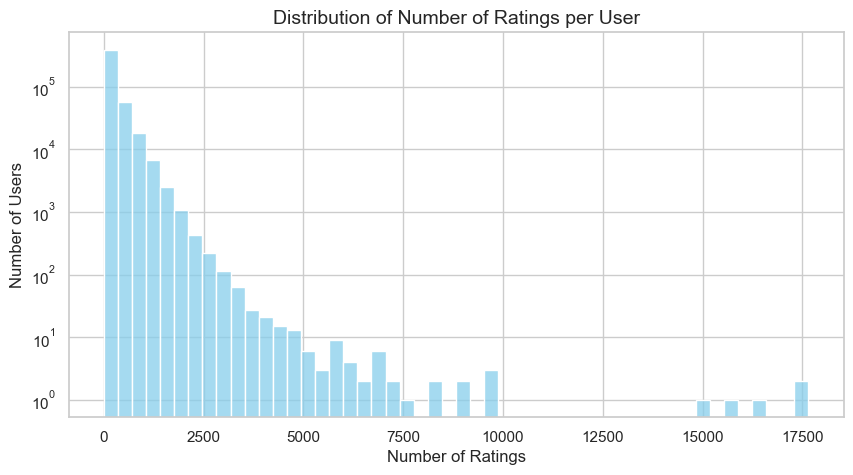

Average ratings per user: 209.25
Median ratings per user: 96.00


In [7]:
# 2. Number of Ratings per User
user_rating_counts = ratings.groupby('user_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(user_rating_counts, bins=50, kde=False, color='skyblue')
plt.title('Distribution of Number of Ratings per User', fontsize=14)
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.yscale('log') # Log scale because of right skewness
plt.show()

print(f"Average ratings per user: {user_rating_counts.mean():.2f}")
print(f"Median ratings per user: {user_rating_counts.median():.2f}")

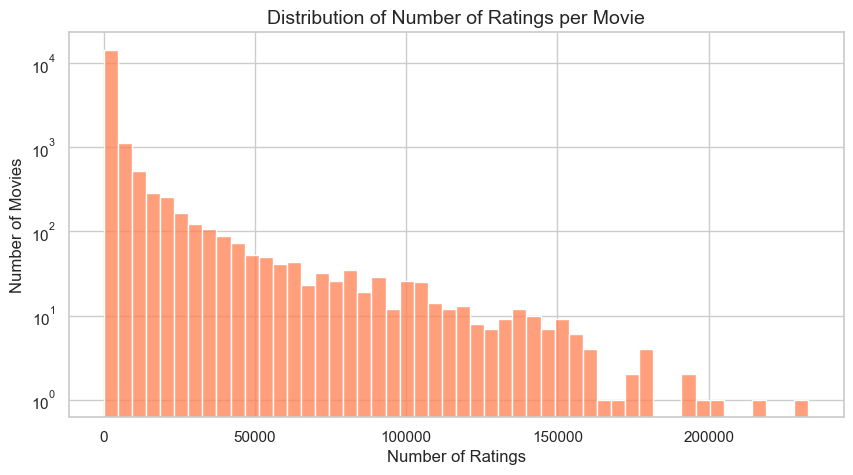

Average ratings per movie: 5656.68
Median ratings per movie: 562.00


In [8]:
# 3. Number of Ratings per Movie
movie_rating_counts = ratings.groupby('movie_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(movie_rating_counts, bins=50, kde=False, color='coral')
plt.title('Distribution of Number of Ratings per Movie', fontsize=14)
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.yscale('log')
plt.show()

print(f"Average ratings per movie: {movie_rating_counts.mean():.2f}")
print(f"Median ratings per movie: {movie_rating_counts.median():.2f}")

In [ ]:
# 4. Top 20 Most Rated Movies
top_movies_id = movie_rating_counts.nlargest(20).index
top_movies_stats = ratings[ratings['movie_id'].isin(top_movies_id)].groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sort by year (latest first)
top_movies_with_titles = pd.merge(top_movies_stats, movies, on='movie_id').sort_values(by=['year', 'num_ratings'], ascending=[False, False])
display(top_movies_with_titles[['title', 'year', 'num_ratings', 'avg_rating']])

,title,year,num_ratings,avg_rating
16,The Day After Tomorrow,2004.0,196397,3.442166
5,"I, Robot",2004.0,155714,3.716461
0,Pirates of the Caribbean: The Curse of the Bla...,2003.0,193941,4.153908
2,Bruce Almighty,2003.0,160454,3.434517
3,The Italian Job,2003.0,156183,3.755364
17,Sweet Home Alabama,2002.0,176539,3.538589
6,The Bourne Identity,2002.0,158601,3.973455
9,Pearl Harbor,2001.0,173596,3.397970
14,Ocean's Eleven,2001.0,160326,3.893161
4,Miss Congeniality,2000.0,232944,3.361267


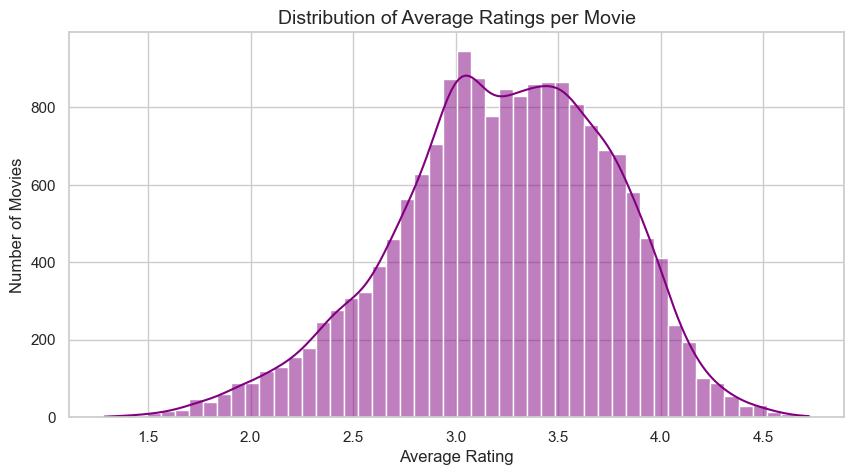

In [11]:
# 5. Distribution of Average Ratings per Movie
movie_avg_ratings = ratings.groupby('movie_id')['rating'].mean()

plt.figure(figsize=(10, 5))
sns.histplot(movie_avg_ratings, bins=50, kde=True, color='purple')
plt.title('Distribution of Average Ratings per Movie', fontsize=14)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.show()

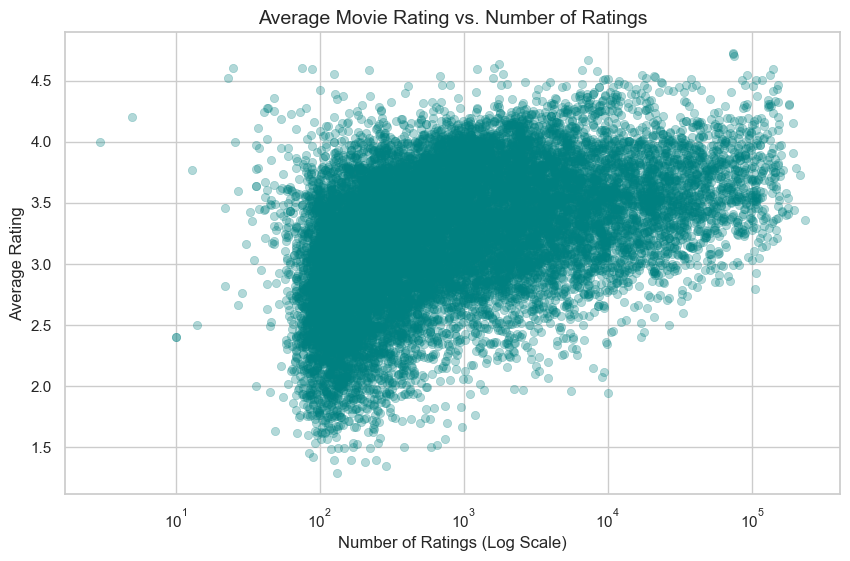

In [ ]:
# 6. Average Rating vs. Number of Ratings

movie_stats = ratings.groupby('movie_id').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='num_ratings', y='avg_rating', data=movie_stats, alpha=0.3, color='teal', edgecolor=None)
plt.title('Average Movie Rating vs. Number of Ratings', fontsize=14)
plt.xlabel('Number of Ratings (Log Scale)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.xscale('log') # Log scale is essential here due to the long tail of popularity
plt.show()

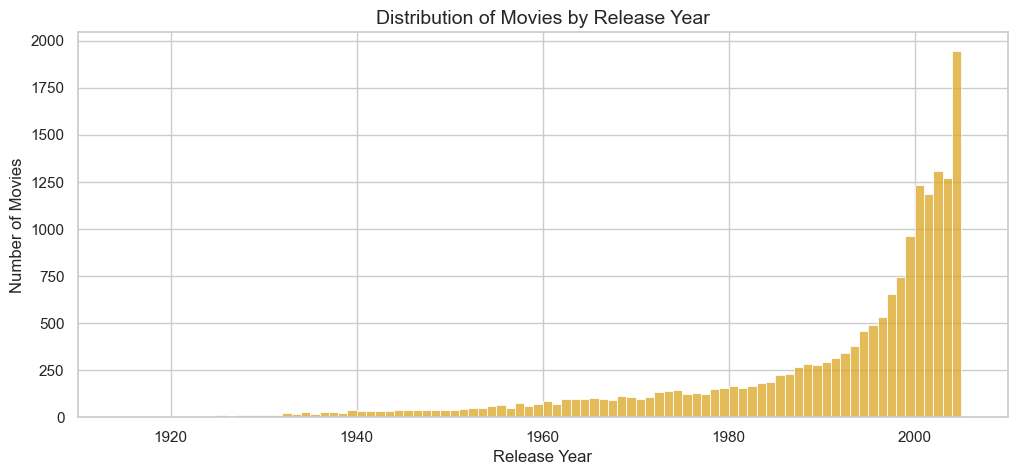

In [13]:
# 7. Distribution of Movies by Release Year
plt.figure(figsize=(12, 5))
sns.histplot(movies['year'].dropna(), bins=int(movies['year'].max() - movies['year'].min()), kde=False, color='goldenrod')
plt.title('Distribution of Movies by Release Year', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xlim(1910, 2010)
plt.show()

In [15]:
# STEP 6: Filter Sparse Data

TOP_USERS = 10000
MIN_MOVIE_RATINGS = 50

# Keep the 10,000 most active users
user_counts = ratings.groupby("user_id").size()

top_users = user_counts.nlargest(TOP_USERS).index

ratings_filtered = ratings[
    ratings["user_id"].isin(top_users)
].copy()

# Keep movies with at least 50 ratings
movie_counts = ratings_filtered.groupby("movie_id").size()

popular_movies = movie_counts[
    movie_counts >= MIN_MOVIE_RATINGS
].index

ratings_filtered = ratings_filtered[
    ratings_filtered["movie_id"].isin(popular_movies)
].copy()

# Summary
print("=" * 50)
print("FILTERED DATASET SUMMARY")
print("=" * 50)

print(f"Original Ratings : {len(ratings):,}")
print(f"Filtered Ratings : {len(ratings_filtered):,}")

print(f"\nOriginal Users : {ratings['user_id'].nunique():,}")
print(f"Filtered Users : {ratings_filtered['user_id'].nunique():,}")

print(f"\nOriginal Movies : {ratings['movie_id'].nunique():,}")
print(f"Filtered Movies : {ratings_filtered['movie_id'].nunique():,}")

print(f"\nData Retained: {(len(ratings_filtered)/len(ratings))*100:.2f}%")

FILTERED DATASET SUMMARY
Original Ratings : 100,479,542
Filtered Ratings : 15,351,759

Original Users : 480,189
Filtered Users : 10,000

Original Movies : 17,763
Filtered Movies : 13,503

Data Retained: 15.28%


In [16]:

# STEP 7: Build the User–Item Sparse Matrix

from scipy.sparse import csr_matrix

# Create consecutive matrix positions for user IDs and movie IDs
user_ids = ratings_filtered["user_id"].unique()
movie_ids = ratings_filtered["movie_id"].unique()

user_to_index = {
    user_id: index
    for index, user_id in enumerate(user_ids)
}
movie_to_index = {
    movie_id: index
    for index, movie_id in enumerate(movie_ids)
}
index_to_user = {
    index: user_id
    for user_id, index in user_to_index.items()
}
index_to_movie = {
    index: movie_id
    for movie_id, index in movie_to_index.items()
}

# Convert IDs into row and column positions
user_indices = ratings_filtered["user_id"].map(user_to_index)
movie_indices = ratings_filtered["movie_id"].map(movie_to_index)

# Build sparse user-item matrix
# Rows = users
# Columns = movies
# Values = ratings
user_item_matrix = csr_matrix(
    (
        ratings_filtered["rating"].astype("float32"),
        (user_indices, movie_indices)
    ),
    shape=(len(user_ids), len(movie_ids))
)

# Verify the matrix
print("User–Item Matrix Created Successfully")
print(f"Matrix shape       : {user_item_matrix.shape}")
print(f"Number of users    : {user_item_matrix.shape[0]:,}")
print(f"Number of movies   : {user_item_matrix.shape[1]:,}")
print(f"Stored ratings     : {user_item_matrix.nnz:,}")

total_cells = (
    user_item_matrix.shape[0]
    * user_item_matrix.shape[1]
)

density = (
    user_item_matrix.nnz
    / total_cells
) * 100

sparsity = 100 - density

print(f"Matrix density     : {density:.4f}%")
print(f"Matrix sparsity    : {sparsity:.4f}%")

User–Item Matrix Created Successfully
Matrix shape       : (10000, 13503)
Number of users    : 10,000
Number of movies   : 13,503
Stored ratings     : 15,351,759
Matrix density     : 11.3691%
Matrix sparsity    : 88.6309%


In [17]:
#item-user sparce matrix

# Rows = movies
# Columns = users
item_user_matrix = user_item_matrix.T.tocsr()

print("\nItem–User Matrix Shape:")
print(item_user_matrix.shape)


Item–User Matrix Shape:
(13503, 10000)


In [ ]:
# STEP 9: Apply Truncated SVD (linear dimentionality reduction)
# applied to user–item matrix

from sklearn.decomposition import TruncatedSVD

N_COMPONENTS = 100

svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=42
)

movie_features = svd.fit_transform(item_user_matrix)

print("Truncated SVD Completed")
print(f"Original item-user shape : {item_user_matrix.shape}")
print(f"Reduced movie shape      : {movie_features.shape}")

explained_variance = svd.explained_variance_ratio_.sum()

print(f"Number of components     : {N_COMPONENTS}")
print(f"Explained variance       : {explained_variance:.2%}")

Random Forest Regressor

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [20]:
import gc
gc.collect()

32136

In [21]:
# 1. DERIVE USER EMBEDDINGS & SAMPLE RATINGS
# Sample 200,000 ratings from filtered dataset for efficient training
SAMPLE_SIZE = 200_000
sampled_df = ratings_filtered.sample(n=SAMPLE_SIZE, random_state=42).copy()

# Map IDs to matrix indices
sampled_df["user_idx"] = sampled_df["user_id"].map(user_to_index)
sampled_df["movie_idx"] = sampled_df["movie_id"].map(movie_to_index)
sampled_df = sampled_df.dropna(subset=["user_idx", "movie_idx"])

user_idxs = sampled_df["user_idx"].astype(int).values
movie_idxs = sampled_df["movie_idx"].astype(int).values
y = sampled_df["rating"].values

# Compute user embeddings safely
user_features = item_user_matrix.T.dot(movie_features)

# Build feature vectors: Concatenate User Vector + Movie Vector (200 features total)
X_user = user_features[user_idxs]
X_movie = movie_features[movie_idxs]
X = np.hstack([X_user, X_movie])

# Clear intermediate dataframes to free RAM
del sampled_df
gc.collect()

# Train / Test split (80% train, 20% test)
X_train, X_test, y_train, y_test, train_user_idxs, test_user_idxs = train_test_split(
    X, y, user_idxs, test_size=0.2, random_state=42
)

In [22]:
import numpy as np
import pandas as pd

# 1. DERIVE USER EMBEDDINGS & SAMPLE RATINGS
# Compute user embeddings safely
user_features = item_user_matrix.T.dot(movie_features)

# Sample a subset of ratings for training efficiency
SAMPLE_SIZE = 200_000 # Use the same sample size as before
sampled_df_new_features = ratings_filtered.sample(n=SAMPLE_SIZE, random_state=42).copy()

# Map IDs to matrix indices (user_to_index and movie_to_index from cell a26bef65 are assumed available)
sampled_df_new_features["user_idx"] = sampled_df_new_features["user_id"].map(user_to_index)
sampled_df_new_features["movie_idx"] = sampled_df_new_features["movie_id"].map(movie_to_index)
sampled_df_new_features = sampled_df_new_features.dropna(subset=["user_idx", "movie_idx"])

user_idxs_new = sampled_df_new_features["user_idx"].astype(int).values
movie_idxs_new = sampled_df_new_features["movie_idx"].astype(int).values
y_new = sampled_df_new_features["rating"].values

# Combine SVD features (user_features, movie_features) as the base for clustering
X_user_svd = user_features[user_idxs_new]
X_movie_svd = movie_features[movie_idxs_new]

X_svd_features_only = np.hstack([
    X_user_svd,
    X_movie_svd
])

# Clear intermediate dataframes to free RAM if needed
gc.collect()

print("Base feature matrix shape (SVD features only) for clustering:", X_svd_features_only.shape)

Base feature matrix shape (SVD features only) for clustering: (200000, 200)


Calculating inertia for movie features across different cluster numbers...


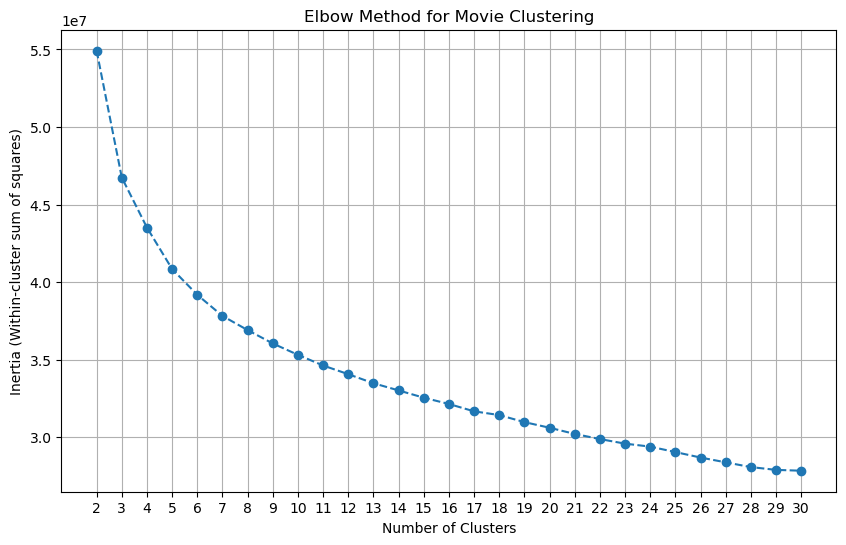

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Range of clusters to try
range_n_clusters = range(2, 31) # From 2 to 30 clusters

# Store inertia values
inertias_movies = []

print("Calculating inertia for movie features across different cluster numbers...")
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init for robust centroid initialization
    kmeans.fit(movie_features)
    inertias_movies.append(kmeans.inertia_)

# Plot the elbow curve for movie features
fig_movie_elbow = plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertias_movies, marker='o', linestyle='--')
plt.title('Elbow Method for Movie Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(list(range_n_clusters))
plt.grid(True)
plt.show()

Calculating inertia for user features across different cluster numbers...


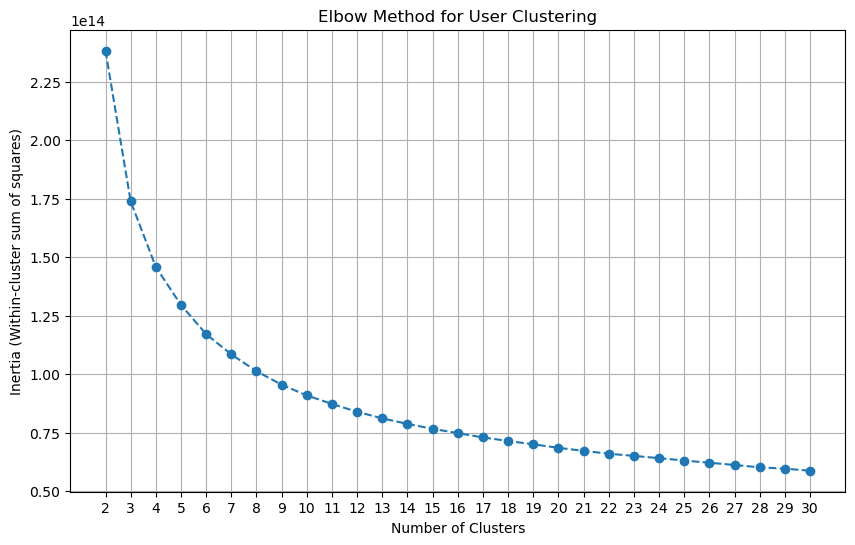

In [35]:
# Store inertia values
inertias_users = []

print("Calculating inertia for user features across different cluster numbers...")
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init for robust centroid initialization
    kmeans.fit(user_features)
    inertias_users.append(kmeans.inertia_)

# Plot the elbow curve for user features
fig_user_elbow = plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertias_users, marker='o', linestyle='--')
plt.title('Elbow Method for User Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(list(range_n_clusters))
plt.grid(True)
plt.show()

In [36]:
from sklearn.cluster import KMeans

# Define number of clusters for users and movies
N_USER_CLUSTERS = 6
N_MOVIE_CLUSTERS = 6

# Cluster Users
print(f"Clustering {len(user_features)} users into {N_USER_CLUSTERS} clusters...")
kmeans_users = KMeans(n_clusters=N_USER_CLUSTERS, random_state=42, n_init=10)
user_cluster_labels = kmeans_users.fit_predict(user_features)

# Cluster Movies
print(f"Clustering {len(movie_features)} movies into {N_MOVIE_CLUSTERS} clusters...")
kmeans_movies = KMeans(n_clusters=N_MOVIE_CLUSTERS, random_state=42, n_init=10)
movie_cluster_labels = kmeans_movies.fit_predict(movie_features)

# Create mappings from original user/movie indices to cluster labels
user_idx_to_cluster = {idx: label for idx, label in enumerate(user_cluster_labels)}
movie_idx_to_cluster = {idx: label for idx, label in enumerate(movie_cluster_labels)}

# Add cluster features to your sampled_df_new_features
sampled_df_new_features['user_cluster'] = sampled_df_new_features['user_idx'].map(user_idx_to_cluster)
sampled_df_new_features['movie_cluster'] = sampled_df_new_features['movie_idx'].map(movie_idx_to_cluster)

# Rebuild the combined feature matrix (X_with_clusters) by adding the new cluster features
X_with_clusters = np.hstack([
    X_svd_features_only, # Start with only SVD features as the base
    sampled_df_new_features[['user_cluster', 'movie_cluster']].values
])

# Now you would use X_with_clusters, y_new, user_idxs_new for train/test split and modeling
# (You might want to rerun your train_test_split from cell `e22bb94e` with X_with_clusters and y_new)

print("Combined feature matrix shape with SVD and cluster features:", X_with_clusters.shape)
print("First 5 rows of cluster features:")
display(sampled_df_new_features[['user_cluster', 'movie_cluster']].head())

# Clean up intermediate variables to free memory
del user_cluster_labels, movie_cluster_labels, user_idx_to_cluster, movie_idx_to_cluster
gc.collect()

Clustering 10000 users into 6 clusters...
Clustering 13503 movies into 6 clusters...
Combined feature matrix shape with SVD and cluster features: (200000, 202)
First 5 rows of cluster features:


,user_cluster,movie_cluster
20124518,4,0
42030700,1,1
45766865,0,4
72698996,4,1
8533849,3,0


38

In [37]:
# Train / Test split (80% train, 20% test)
X_train, X_test, y_train, y_test, train_user_idxs, test_user_idxs = train_test_split(
    X_with_clusters, y_new, user_idxs_new, test_size=0.2, random_state=42
)

In [ ]:
'''SVD & K-NN model with similar train/test setup as RF'''

In [23]:
regressor = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",
    max_depth=None,
    criterion="squared_error",
    random_state=42,
    oob_score=True
)

regressor.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [14]:
# TRAIN & EVALUATE RANDOM FOREST
from sklearn.model_selection import GridSearchCV

param_grid = {
 "n_estimators": [200], #50, 100, 150, 
 "max_features": ["sqrt"], # "log2"
 "max_depth": [None], #8, 15, 20, 
 "criterion": ['squared_error']
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
 cv=5, n_jobs=-1, verbose=2)

# Fit Grid Search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Access the best model
best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, n_estimators=200; total time= 5.4min
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, n_estimators=200; total time= 5.4min
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, n_estimators=200; total time= 5.4min
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, n_estimators=200; total time= 5.4min
[CV] END criterion=squared_error, max_depth=None, max_features=sqrt, n_estimators=200; total time= 5.4min
Best parameters found: {'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best cross-validation score: 0.2550


In [24]:
# Predict & clip to valid rating range [1, 5]
rf_preds_test = regressor.predict(X_test)
rf_preds_test = np.clip(rf_preds_test, 1.0, 5.0)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds_test))
rf_mae = mean_absolute_error(y_test, rf_preds_test)

print(rf_rmse)
print(rf_mae)

0.9509955789855177
0.7626182499999999


Precision@K and NDCG

In [25]:
from sklearn.metrics import ndcg_score

def evaluate_ranking_metrics(user_indices, y_true, y_pred, k=10, relevance_threshold=4.0):

  # df that groups predictions by user
  df = pd.DataFrame({
      'user_idx': user_indices,
      'y_true': y_true,
      'y_pred': y_pred
  })

  precisions = []
  ndcgs = []

  # eval ranking for each user
  for user, group in df.groupby('user_idx'):
    true_ratings = group['y_true'].values
    pred_ratings = group['y_pred'].values

    # precision@K
    top_k_pred_indices = np.argsort(pred_ratings)[::-1][:k]
    relevant_in_top_k = sum(true_ratings[top_k_pred_indices] >= relevance_threshold)

    actual_k = min(k, len(true_ratings))
    precision_at_k = relevant_in_top_k / actual_k
    precisions.append(precision_at_k)

    # NDCG@K
    try:
      ndcg = ndcg_score([true_ratings], [pred_ratings], k=k)
      ndcgs.append(ndcg)
    except ValueError:
      continue

  return np.mean(precisions), np.mean(ndcgs)


In [26]:
k_value = 10

# Random Forest Model
rf_precision, rf_ndcg = evaluate_ranking_metrics(
    user_indices=test_user_idxs,
    y_true=y_test,
    y_pred=rf_preds_test,
    k=k_value
)

print(rf_precision, rf_ndcg)

0.489423763602699 0.9668933099029979


In [ ]:
# Relevance Threshold: a liked movie as a rating of > 4.0 stars.

In [28]:
def generate_recommendations(user_id, model, user_features_matrix, movie_features_matrix, user_item_mat, top_k=10):
    """
    Generates top-k movie recommendations for a given user,
    explicitly excluding any already-seen movies (train + test).
    """
    if user_id not in user_to_index:
        print(f"User {user_id} not in the filtered dataset.")
        return None

    user_idx = user_to_index[user_id]

    # 1. Identify all movies and the ones the user has already interacted with
    all_movie_idxs = np.arange(len(movie_to_index))
    
    # user_item_mat contains all historical interactions (train & test)
    # .nonzero()[1] gets the column indices (movie_idxs) where the user has a rating
    seen_movie_idxs = user_item_mat[user_idx, :].nonzero()[1]

    # 2. Exclude already seen movies
    unseen_movie_idxs = np.setdiff1d(all_movie_idxs, seen_movie_idxs)

    # 3. Prepare features for the model
    # Repeat the user's features for each unseen movie
    u_features = np.tile(user_features_matrix[user_idx], (len(unseen_movie_idxs), 1))
    m_features = movie_features_matrix[unseen_movie_idxs]

    # Combine user and movie features (matching the X_train format: [user_features, movie_features])
    X_unseen = np.hstack([u_features, m_features])

    # 4. Predict ratings for all unseen movies
    predicted_ratings = model.predict(X_unseen)
    predicted_ratings = np.clip(predicted_ratings, 1.0, 5.0)

    # 5. Sort and select the top K highest predicted ratings
    top_k_indices = np.argsort(predicted_ratings)[::-1][:top_k]
    top_movie_idxs = unseen_movie_idxs[top_k_indices]
    top_predictions = predicted_ratings[top_k_indices]

    # 6. Map back to movie IDs and titles
    recommendations = []
    for m_idx, score in zip(top_movie_idxs, top_predictions):
        m_id = index_to_movie[m_idx]
        title = movies.loc[movies['movie_id'] == m_id, 'title'].values[0]
        recommendations.append({
            'movie_id': m_id,
            'title': title,
            'predicted_rating': score
        })

    return pd.DataFrame(recommendations)

In [29]:
# Test function
sample_user_idx = test_user_idxs[0]
sample_user_id = index_to_user[sample_user_idx]

print(f"Generating unseen movie recommendations for User ID {sample_user_id}...")

top_recommendations = generate_recommendations(
    user_id=sample_user_id,
    model=regressor, # Using the best model from GridSearchCV
    user_features_matrix=user_features,
    movie_features_matrix=movie_features,
    user_item_mat=user_item_matrix,
    top_k=10
)

display(top_recommendations)

Generating unseen movie recommendations for User ID 1747859...


,movie_id,title,predicted_rating
0,5103,The Simpsons: Season 5,4.540
1,16587,The Simpsons: Season 4,4.525
2,8535,The Simpsons: Season 2,4.380
3,9628,Star Wars: Episode VI: Return of the Jedi,4.360
4,3046,The Simpsons: Treehouse of Horror,4.300
5,1020,The Simpsons: Season 1,4.285
6,5760,The Sopranos: Season 3,4.275
7,2172,The Simpsons: Season 3,4.250
8,11662,The Sopranos: Season 5,4.235
9,10080,Six Feet Under: Season 2,4.215


In [ ]:
"""
    Generates top-k movie recommendations for a given user using the SVD model.
"""

In [ ]:
"""
    Generates top-k movie recommendations for a given user using the KNN model.
"""

In [ ]:
# --- Example Usage ---
print(f"Generating unseen movie recommendations for User ID {sample_user_id} using SVD...")

In [ ]:
# --- Example Usage ---
print(f"Generating unseen movie recommendations for User ID {sample_user_id} using KNN...")

In [31]:
def show_user_true_favorites(target_user_id, top_n=10):
    # 1. Pull all rows where this user gave a rating
    user_ratings = ratings_filtered[ratings_filtered["user_id"] == target_user_id]
    
    # 2. Sort by highest rating (5 stars first)
    top_actual = user_ratings.sort_values(by="rating", ascending=False).head(top_n)
    
    favorite_records = []
    for _, row in top_actual.iterrows():
        movie_id = row["movie_id"]
        rating = row["rating"]
        
        # Match with movie titles and years
        movie_row = movies[movies["movie_id"] == movie_id]
        if not movie_row.empty:
            title = movie_row["title"].values[0]
            year = movie_row["year"].values[0]
        else:
            title = f"Movie ID {movie_id}"
            year = "Unknown"
            
        favorite_records.append({
            "Movie ID": movie_id,
            "Title": title,
            "Year": year,
            "Actual Rating": int(rating)
        })
        
    fav_df = pd.DataFrame(favorite_records)
    print(f"\n--- USER {target_user_id}'S ACTUAL TOP FAVORITES ---")
    return fav_df

# Run it for the same sample user
sample_user_id = int(ratings_filtered["user_id"].iloc[0])
actual_favorites_table = show_user_true_favorites(sample_user_id, top_n=10)
display(actual_favorites_table)


--- USER 1488844'S ACTUAL TOP FAVORITES ---


,Movie ID,Title,Year,Actual Rating
0,8292,Star Wars: Clone Wars: Vol. 1,2004.0,5
1,12074,The Sound of Music,1965.0,5
2,3427,Men in Black II,2002.0,5
3,5434,Mission to Mars,2000.0,5
4,8099,Reign of Fire,2002.0,5
5,8079,Interview with the Vampire,1994.0,5
6,3368,The Family Man,2000.0,5
7,16698,Highlander,1986.0,5
8,5497,Memphis Belle,1944.0,5
9,7850,Quantum Leap: Season 3,1990.0,5


In [ ]:
# Popularity-based baseline model
def get_popularity_baseline(ratings_df, movies_df, min_ratings=500, top_k=10):
    """
    Generates global popularity-based recommendations.
    Returns top_k movies sorted by average rating, requiring a minimum number of ratings.
    """
    # Calculate stats for all movies
    movie_stats = ratings_df.groupby('movie_id').agg(
        num_ratings=('rating', 'count'),
        avg_rating=('rating', 'mean')
    ).reset_index()
    
    # Filter out movies with too few ratings to avoid obscure 5-star movies
    popular_movies = movie_stats[movie_stats['num_ratings'] >= min_ratings]
    
    # Sort by highest average rating, then by number of ratings
    top_popular = popular_movies.sort_values(by=['avg_rating', 'num_ratings'], ascending=[False, False]).head(top_k)
    
    # Merge with titles
    baseline_recs = pd.merge(top_popular, movies_df, on='movie_id')
    
    return baseline_recs[['movie_id', 'title', 'avg_rating', 'num_ratings']]

baseline_recommendations = get_popularity_baseline(ratings_filtered, movies, min_ratings=1000, top_k=10)

print("--- Global Popularity Baseline Recommendations ---")
display(baseline_recommendations)

--- Global Popularity Baseline Recommendations (Same for everyone) ---


,movie_id,title,avg_rating,num_ratings
0,14961,Lord of the Rings: The Return of the King: Ext...,4.682234,6552
1,7230,The Lord of the Rings: The Fellowship of the R...,4.678973,6663
2,7057,Lord of the Rings: The Two Towers: Extended Ed...,4.666667,6762
3,5582,Star Wars: Episode V: The Empire Strikes Back,4.556143,7757
4,10042,Raiders of the Lost Ark,4.538073,9298
5,14240,Lord of the Rings: The Return of the King,4.535355,8641
6,16265,Star Wars: Episode IV: A New Hope,4.519691,7389
7,14550,The Shawshank Redemption: Special Edition,4.507584,9098
8,12293,The Godfather,4.459695,8138
9,5103,The Simpsons: Season 5,4.447972,2835


In [ ]:
# Qualitative comparison
# Pick a user from the test set for qualitative evaluation
eval_user_idx = test_user_idxs[5] # Pick a different random user
eval_user_id = index_to_user[eval_user_idx]

print(f"=== Qualitative Evaluation for User ID: {eval_user_id} ===\n")

# 1. What did this user actually like? (Movies they rated 4 or 5)
user_history_df = ratings_filtered[ratings_filtered['user_id'] == eval_user_id]
high_rated_history = pd.merge(user_history_df[user_history_df['rating'] >= 4], movies, on='movie_id')

print("What the user ACTUALLY liked (Ratings >= 4):")
display(high_rated_history[['title', 'rating', 'year']].sort_values(by='rating', ascending=False).head(10))

# 2. Baseline Recommendations (Already computed above)
print("\nBaseline Recommendations (Popularity):")
display(baseline_recommendations[['title', 'avg_rating']])

# 3. Personalized Recommendations (Random Forest)
print("\nPersonalized Recommendations (Random Forest):")
personalized_recs = generate_recommendations(
    user_id=eval_user_id,
    model=regressor, 
    user_features_matrix=user_features,
    movie_features_matrix=movie_features,
    user_item_mat=user_item_matrix,
    top_k=10
)

if personalized_recs is not None:
    display(personalized_recs[['title', 'predicted_rating']])
else:
    print("Could not generate personalized recommendations for this user.")

=== Qualitative Evaluation for User ID: 2390353 ===

--> What the user ACTUALLY liked (Ratings >= 4):


,title,rating,year
485,Lois & Clark: The New Adventures of Superman: ...,5,1993.0
397,Doctor Who: Lost in Time: The William Hartnell...,5,1975.0
388,The Best of He-Man and the Masters of the Univ...,5,1983.0
782,12 Monkeys,5,1995.0
391,Blade,5,1998.0
780,Uncle Buck,5,1989.0
778,Kill Bill: Vol. 1,5,2003.0
396,Batman the Animated Series: Vol. 1,5,1992.0
776,Dragon Ball Z: Babidi,5,2003.0
456,Seven,5,1995.0



--> Baseline Recommendations (Popularity):


,title,avg_rating
0,Lord of the Rings: The Return of the King: Ext...,4.682234
1,The Lord of the Rings: The Fellowship of the R...,4.678973
2,Lord of the Rings: The Two Towers: Extended Ed...,4.666667
3,Star Wars: Episode V: The Empire Strikes Back,4.556143
4,Raiders of the Lost Ark,4.538073
5,Lord of the Rings: The Return of the King,4.535355
6,Star Wars: Episode IV: A New Hope,4.519691
7,The Shawshank Redemption: Special Edition,4.507584
8,The Godfather,4.459695
9,The Simpsons: Season 5,4.447972



--> Personalized Recommendations (Random Forest):


,title,predicted_rating
0,Raiders of the Lost Ark,4.540
1,Family Guy: Vol. 2: Season 3,4.300
2,Shrek (Full-screen),4.290
3,Blue Seed,4.225
4,Samurai Champloo,4.185
5,Wolf's Rain,4.185
6,Simpsons Gone Wild,4.180
7,Inu-Yasha: The Movie: Affections Touching Acro...,4.160
8,Transformers: Season 2: Part I,4.155
9,Six Feet Under: Season 2,4.155
